Heart Disease UCI - Full ML Analysis
=====================================
Steps:
  1. Load & preprocess
  2. Basic statistical check
  3. Correlation analysis
  4. PCA (95% variance threshold)
  5. K-Means clustering + elbow plot
  6. Random Forest + SVM to predict clusters
  7. Accuracy & confusion matrix comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("heart_disease_uci.csv")
print("Raw shape:", df.shape)

Raw shape: (920, 16)


In [26]:
numerical_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

for col in numerical_cols:
    print(f"\nFeature: {col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Range:", df[col].max() - df[col].min())


Feature: age
Minimum: 28
Maximum: 77
Range: 49

Feature: trestbps
Minimum: 0.0
Maximum: 200.0
Range: 200.0

Feature: chol
Minimum: 0.0
Maximum: 603.0
Range: 603.0

Feature: thalch
Minimum: 60.0
Maximum: 202.0
Range: 142.0

Feature: oldpeak
Minimum: -2.6
Maximum: 6.2
Range: 8.8


In [27]:
# Fill missing numerical values with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [28]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype == 'bool':
        df[col] = le.fit_transform(df[col].astype(str))

print(df.head())

   id  age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   1   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   2   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   3   67    1        0   0     120.0  229.0    0        0   129.0      1   
3   4   37    1        0   2     130.0  250.0    0        1   187.0      0   
4   5   41    0        0   1     130.0  204.0    0        0   172.0      0   

   oldpeak  slope   ca  thal  num  
0      2.3      0  0.0     0    0  
1      1.5      1  3.0     1    2  
2      2.6      1  2.0     2    1  
3      3.5      0  0.0     1    0  
4      1.4      2  0.0     1    0  


In [29]:
corr = X.corr()
print("\n" + "="*55)
print("TOP CORRELATIONS (|r| > 0.25)")
print("="*55)
pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.25:
            pairs.append((corr.columns[i], corr.columns[j], r))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for a, b, r in pairs:
    print(f"  {a:12s} ↔ {b:12s}  r = {r:+.3f}")


TOP CORRELATIONS (|r| > 0.25)
  id           ↔ dataset       r = +0.949
  id           ↔ restecg       r = +0.479
  dataset      ↔ restecg       r = +0.460
  id           ↔ thalch        r = -0.437
  oldpeak      ↔ num           r = +0.422
  dataset      ↔ chol          r = -0.413
  dataset      ↔ thalch        r = -0.382
  exang        ↔ oldpeak       r = +0.382
  id           ↔ chol          r = -0.373
  cp           ↔ exang         r = -0.361
  age          ↔ thalch        r = -0.353
  thalch       ↔ num           r = -0.351
  exang        ↔ num           r = +0.351
  thalch       ↔ exang         r = -0.350
  age          ↔ num           r = +0.340
  ca           ↔ num           r = +0.321
  cp           ↔ num           r = -0.315
  id           ↔ slope         r = -0.305
  dataset      ↔ slope         r = -0.297
  thalch       ↔ slope         r = +0.291
  cp           ↔ thalch        r = +0.289
  sex          ↔ dataset       r = +0.286
  id           ↔ sex           r = +0.280
  d

In [30]:
corr_matrix = df.corr()

print(corr_matrix)

                id       age       sex   dataset        cp  trestbps  \
id        1.000000  0.239301  0.280053  0.949062 -0.189430  0.049369   
age       0.239301  1.000000  0.056889  0.235076 -0.076519  0.235253   
sex       0.280053  0.056889  1.000000  0.285734 -0.125933  0.001073   
dataset   0.949062  0.235076  0.285734  1.000000 -0.150334  0.019468   
cp       -0.189430 -0.076519 -0.125933 -0.150334  1.000000 -0.022565   
trestbps  0.049369  0.235253  0.001073  0.019468 -0.022565  1.000000   
chol     -0.372984 -0.084499 -0.193782 -0.412534  0.064510  0.088290   
fbs       0.148983  0.219915  0.075370  0.170110  0.006370  0.148398   
restecg   0.479012 -0.006652  0.072160  0.460189 -0.070150  0.015160   
thalch   -0.436795 -0.353471 -0.177135 -0.382415  0.289362 -0.104616   
exang     0.166239  0.160910  0.155204  0.129326 -0.360513  0.149040   
oldpeak   0.046473  0.248082  0.102733  0.048533 -0.173515  0.160268   
slope    -0.305000 -0.077087 -0.105805 -0.297152  0.113415 -0.05

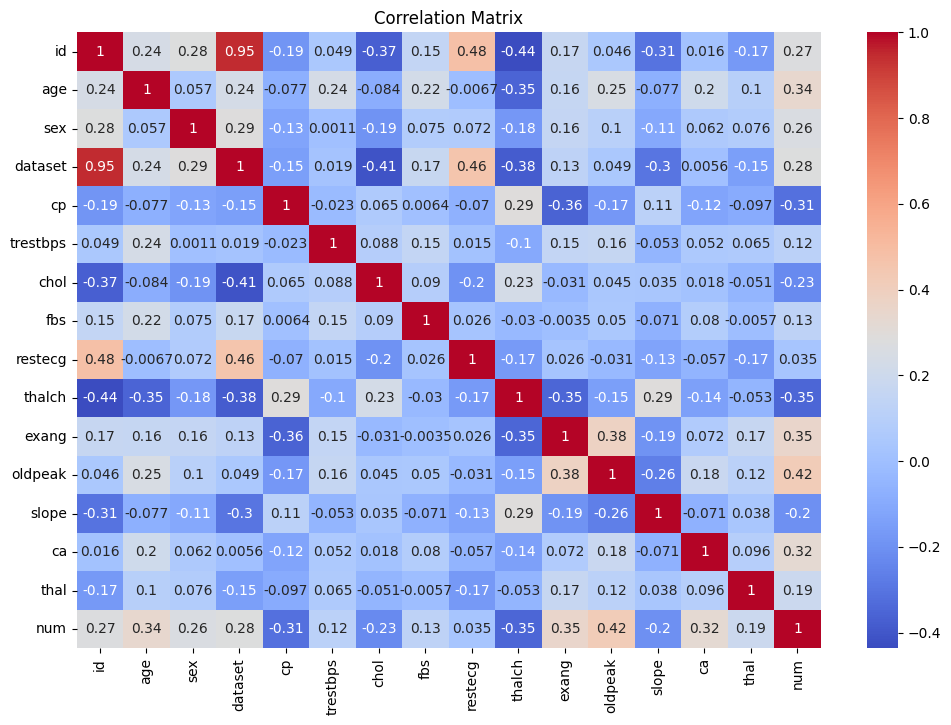

In [31]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [32]:
# Separate features
X = df.drop('num', axis=1)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
pca = PCA(n_components=0.935555)
X_pca = pca.fit_transform(X_scaled)

print("Original Shape:", X_scaled.shape)
print("Reduced Shape:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Captured:")
print(np.sum(pca.explained_variance_ratio_))

Original Shape: (920, 15)
Reduced Shape: (920, 12)

Explained Variance Ratio:
[0.22457264 0.13285188 0.0882486  0.07540049 0.06448168 0.06278465
 0.05867814 0.05267499 0.05034831 0.04781319 0.04113726 0.03695829]

Total Variance Captured:
0.9359501172428343


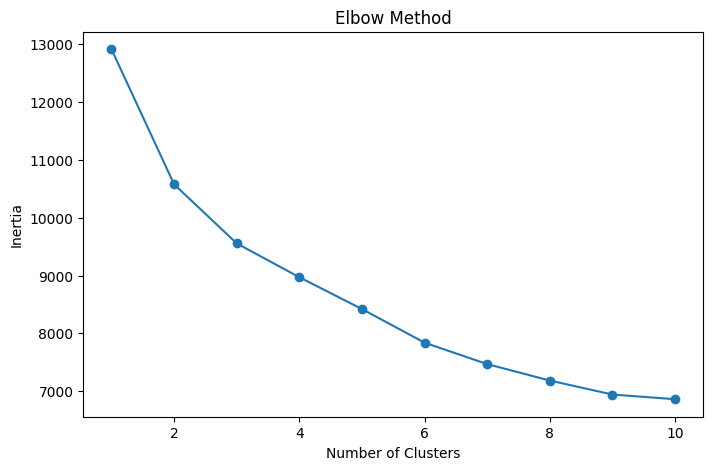

In [62]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [63]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Add clusters to dataframe
df['Cluster'] = clusters

print(df[['Cluster']].head())

   Cluster
0        0
1        2
2        2
3        0
4        0


In [44]:
# Features and labels
X_final = X_pca
y_final = clusters

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42
)

In [45]:
# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Predictions
rf_pred = rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

# Confusion Matrix
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9782608695652174

Random Forest Confusion Matrix:
[[81  0  1]
 [ 0 76  0]
 [ 1  2 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        82
           1       0.97      1.00      0.99        76
           2       0.96      0.88      0.92        26

    accuracy                           0.98       184
   macro avg       0.97      0.96      0.96       184
weighted avg       0.98      0.98      0.98       184



In [46]:
# Train SVM
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)

# Predictions
svm_pred = svm.predict(X_test)

# Accuracy
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_accuracy)

# Confusion Matrix
print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.967391304347826

SVM Confusion Matrix:
[[81  1  0]
 [ 2 74  0]
 [ 1  2 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98        82
           1       0.96      0.97      0.97        76
           2       1.00      0.88      0.94        26

    accuracy                           0.97       184
   macro avg       0.98      0.95      0.96       184
weighted avg       0.97      0.97      0.97       184



In [47]:
print("Random Forest Accuracy:", rf_accuracy)
print("SVM Accuracy:", svm_accuracy)

Random Forest Accuracy: 0.9782608695652174
SVM Accuracy: 0.967391304347826


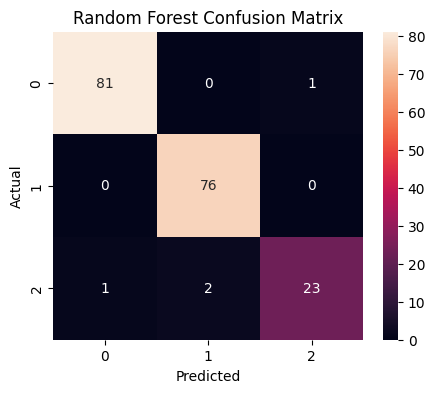

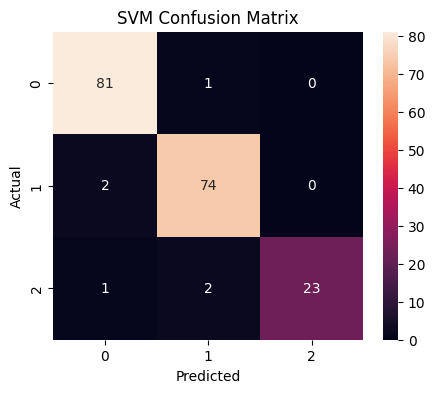

In [48]:
# Random Forest confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# SVM confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()